# 04 — SHAP Analysis

Interprets the trained models using SHAP values from Module 9.
This notebook re-displays the saved figures inline and adds a few
exploratory views (waterfall plots, prediction-by-concentration
walkthroughs) on top of the static PDFs Module 9 already produced.

Covers:
- Global feature importance across endpoints
- Summary plots per endpoint
- Dependence plots for concentration and top compounds
- Biological interpretation table
- Waterfall plot for a single example prediction
- SHAP value trajectory across the locked experimental concentrations

**Inputs:** `outputs/shap/shap_values.csv`,
`outputs/shap/biological_interpretation_table.csv`,
`outputs/shap/figures/*.pdf`, trained models in `models/`

Run Module 9 first if these files don't exist yet:
```bash
python src/module_09_shap.py
```

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import IFrame, display

sys.path.insert(0, "../src")
from utils import load_config, load_json

PROJECT_ROOT = Path("../..")
config = load_config(str(PROJECT_ROOT / "config" / "config.yaml"))

plt.style.use(config["FIGURES"].get("style", "seaborn-v0_8-whitegrid"))

ENDPOINTS = ["germination_percent", "root_length_mm", "shoot_length_mm"]
SHAP_VALUES_PATH = PROJECT_ROOT / "outputs" / "shap" / "shap_values.csv"
INTERP_PATH = PROJECT_ROOT / "outputs" / "shap" / "biological_interpretation_table.csv"
FIG_DIR = PROJECT_ROOT / "outputs" / "shap" / "figures"

assert SHAP_VALUES_PATH.exists(), (
    f"'{SHAP_VALUES_PATH}' not found. Run `python src/module_09_shap.py` first."
)

shap_values_df = pd.read_csv(SHAP_VALUES_PATH, index_col=0)
print(f"SHAP values loaded: {shap_values_df.shape}")
shap_values_df.head()

SHAP values loaded: (3000, 218)


c:\Users\rudsi\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,incubation_days,tds_mg_per_ml,confidence,incability_days,inculation_days,extraction_concentration,effect_on_growth,effect_on_nematodes,reference,hypocotyl_length,...,species_donor_acmella_oleracea,species_donor_ageratina_adenophora,species_donor_chromolaena_odorata,species_donor_eucalyptus_globulus,species_donor_lantana_camara,species_donor_other,species_donor_parthenium_hysterophorus,osmotic_inhibition_score,osmotic_correction_approximate,endpoint
incubation_temp_c,,,,,,,,,,,,,,,,,,,,,
0.0,0.0,-3.264637,-0.000076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.005631,0.103805,0.001854,0.000308,-0.002518,0.006171,-6.862058,0.0,germination_percent
0.0,0.0,1.360104,-0.000247,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.009337,-0.029861,0.004673,-0.000012,-0.000204,0.005899,2.246160,0.0,germination_percent
0.0,0.0,1.040321,-0.000361,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.008360,-0.042663,0.004432,0.000431,-0.000222,-0.105255,1.638386,0.0,germination_percent
0.0,0.0,1.707287,-0.000337,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.008782,-0.040366,0.008899,-0.000016,-0.000204,0.009167,2.666258,0.0,germination_percent
0.0,0.0,-3.070608,-0.000909,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.004913,-0.013308,0.002382,-0.000017,-0.002662,0.004399,-6.828061,0.0,germination_percent


## 1. Pre-rendered figures from Module 9

Module 9 already generated publication-quality PDFs. Listing what's available:

In [2]:
if FIG_DIR.exists():
    figs = sorted(FIG_DIR.glob("*.pdf"))
    print(f"{len(figs)} figures found in {FIG_DIR}:")
    for f in figs:
        print(f"  - {f.name}")
else:
    print("No SHAP figures directory found.")

20 figures found in ..\..\outputs\shap\figures:
  - shap_dependence_germination_percent_compound_caffeic_acid.pdf
  - shap_dependence_germination_percent_compound_chlorogenic_acid.pdf
  - shap_dependence_germination_percent_compound_luteolin_x_compound_caryophylle.pdf
  - shap_dependence_germination_percent_concentration.pdf
  - shap_dependence_germination_percent_log_concentration.pdf
  - shap_dependence_root_length_mm_compound_alpha_pinene.pdf
  - shap_dependence_root_length_mm_compound_luteolin.pdf
  - shap_dependence_root_length_mm_compound_luteolin_x_compound_caryophylle.pdf
  - shap_dependence_root_length_mm_concentration.pdf
  - shap_dependence_root_length_mm_log_concentration.pdf
  - shap_dependence_shoot_length_mm_compound_alpha_pinene.pdf
  - shap_dependence_shoot_length_mm_compound_caffeic_acid.pdf
  - shap_dependence_shoot_length_mm_compound_luteolin_x_compound_caryophylle.pdf
  - shap_dependence_shoot_length_mm_concentration.pdf
  - shap_dependence_shoot_length_mm_log_conc

In [3]:
# Display the global feature importance barplot inline if present (as a link — PDFs
# don't render directly in notebook cells, but this gives a quick way to open it).
barplot_path = FIG_DIR / "shap_feature_importance_barplot.pdf"
if barplot_path.exists():
    print(f"Open this file to view the global importance barplot:\n{barplot_path.resolve()}")
else:
    print("Global importance barplot not found.")

Open this file to view the global importance barplot:
C:\Users\rudsi\Desktop\Expo-2026\outputs\shap\figures\shap_feature_importance_barplot.pdf


## 2. Biological interpretation table

Top features per endpoint, ranked by mean |SHAP|, with hypothesised biological mechanisms.

In [4]:
if INTERP_PATH.exists():
    interp_df = pd.read_csv(INTERP_PATH)
    for ep in ENDPOINTS:
        ep_table = interp_df[interp_df["endpoint"] == ep].head(10)
        if not ep_table.empty:
            print(f"\n=== {ep} — top 10 features by |SHAP| ===")
            display(ep_table[["feature", "mean_abs_shap", "direction", "biological_hypothesis"]])
else:
    print("No biological_interpretation_table.csv found.")


=== germination_percent — top 10 features by |SHAP| ===


,feature,mean_abs_shap,direction,biological_hypothesis
0,concentration_x_compound_caffeic_acid,3.166523,negative,NaN
1,concentration_squared,3.161564,positive,High-concentration inhibition consistent with ...
2,osmotic_inhibition_score,2.814091,positive,Osmotic stress confound; expected negative eff...
3,concentration,2.680028,positive,Linear dose-response component
4,log_concentration,2.426908,positive,Log-linear dose-response; Weber-Fechner law
5,tds_mg_per_ml,2.010919,negative,NaN
6,concentration_cubed,1.834141,positive,NaN
7,bio_score_enzyme_inhibition,0.735510,negative,NaN
8,part_root,0.675530,negative,NaN
9,flavonoid_total_x_phenolic_total,0.435828,negative,NaN



=== root_length_mm — top 10 features by |SHAP| ===


,feature,mean_abs_shap,direction,biological_hypothesis
218,osmotic_inhibition_score,7.329268,positive,Osmotic stress confound; expected negative eff...
219,concentration_squared,2.508933,positive,High-concentration inhibition consistent with ...
220,concentration,2.347003,positive,Linear dose-response component
221,concentration_cubed,2.255392,positive,NaN
222,log_concentration,2.139897,positive,Log-linear dose-response; Weber-Fechner law
223,concentration_x_compound_caffeic_acid,1.073130,negative,NaN
224,part_leaf,0.478435,positive,NaN
225,bio_score_antioxidant,0.469473,negative,Antioxidant compounds stimulate ROS scavenging...
226,concentration_x_phenolic_total,0.460609,negative,NaN
227,part_root,0.450551,negative,NaN



=== shoot_length_mm — top 10 features by |SHAP| ===


,feature,mean_abs_shap,direction,biological_hypothesis
436,osmotic_inhibition_score,6.661128,positive,Osmotic stress confound; expected negative eff...
437,log_concentration,3.705059,positive,Log-linear dose-response; Weber-Fechner law
438,concentration_squared,3.616502,positive,High-concentration inhibition consistent with ...
439,concentration_cubed,3.586873,positive,NaN
440,concentration,3.211526,positive,Linear dose-response component
441,concentration_x_compound_caffeic_acid,1.589065,negative,NaN
442,bio_score_ros_scavenger,0.744551,negative,NaN
443,part_root,0.684582,negative,NaN
444,concentration_x_phenolic_total,0.613683,negative,NaN
445,bio_score_antioxidant,0.585996,negative,Antioxidant compounds stimulate ROS scavenging...


## 3. Recreate a summary plot in-notebook

Useful for interactive exploration (hover, zoom) beyond the static PDF.

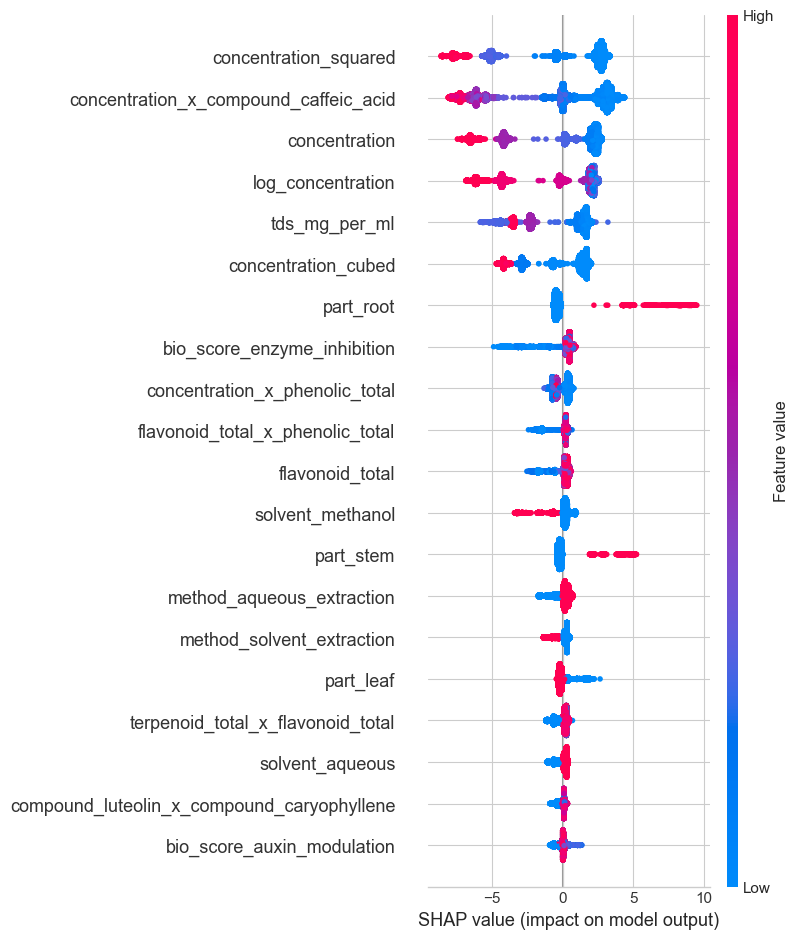

In [6]:
feat_df = pd.read_csv(PROJECT_ROOT / "data" / "features" / "osmotic_corrected_matrix.csv")
full_df = pd.read_csv(PROJECT_ROOT / "data" / "features" / "full_matrix_with_targets.csv")
feature_names = load_json(str(PROJECT_ROOT / "data" / "features" / "feature_names.json"))
feature_names = [f for f in feature_names if f in feat_df.columns]

ENDPOINT_TO_PLOT = ENDPOINTS[0]   # ← change this to explore a different endpoint

model_path = PROJECT_ROOT / "models" / f"best_model_{ENDPOINT_TO_PLOT}.pkl"
assert model_path.exists(), f"No trained model for '{ENDPOINT_TO_PLOT}'. Run Module 6/7 first."

model = joblib.load(model_path)
y = full_df[ENDPOINT_TO_PLOT].dropna()
X = feat_df.loc[y.index][feature_names]

explainer = shap.TreeExplainer(model)
shap_vals = explainer(X, check_additivity=False)

shap.summary_plot(shap_vals.values, X, show=True)

## 4. Dependence plot explorer

Change `FEATURE_TO_PLOT` to explore how any feature drives the prediction.

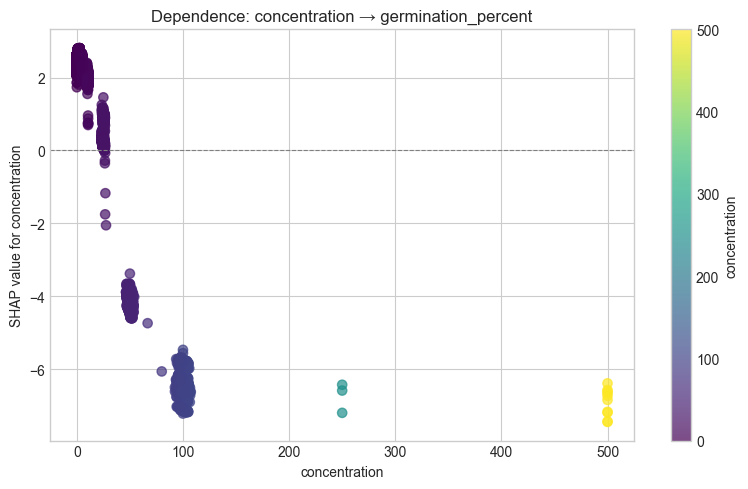

In [7]:
FEATURE_TO_PLOT = "concentration" if "concentration" in X.columns else feature_names[0]

fig, ax = plt.subplots(figsize=(8, 5))
feat_idx = list(X.columns).index(FEATURE_TO_PLOT)
shap_col = shap_vals.values[:, feat_idx]
sc = ax.scatter(X[FEATURE_TO_PLOT], shap_col, c=X[FEATURE_TO_PLOT], cmap="viridis", alpha=0.7, s=45)
plt.colorbar(sc, ax=ax, label=FEATURE_TO_PLOT)
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel(FEATURE_TO_PLOT)
ax.set_ylabel(f"SHAP value for {FEATURE_TO_PLOT}")
ax.set_title(f"Dependence: {FEATURE_TO_PLOT} → {ENDPOINT_TO_PLOT}")
plt.tight_layout()
plt.show()

## 5. Waterfall plot for a single example

Shows how each feature pushes one specific prediction away from the baseline (expected value).

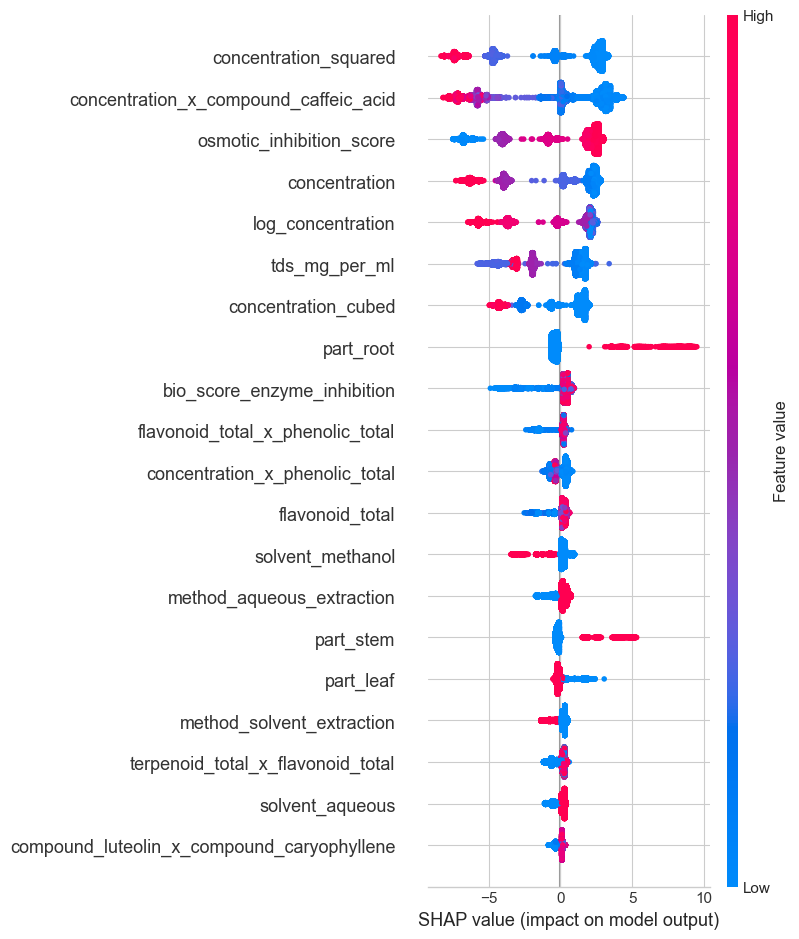

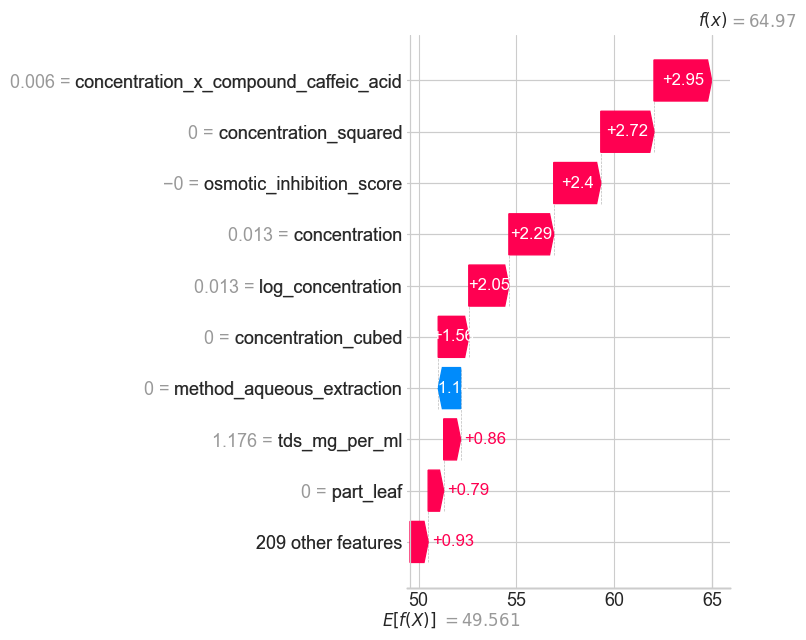

Row index: 0
Actual germination_percent: 75.32
Predicted: 64.97


In [10]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import shap

ENDPOINT_TO_PLOT = ENDPOINTS[0]  # ← Change this to explore a different endpoint

feat_df = pd.read_csv(
    PROJECT_ROOT / "data" / "features" / "osmotic_corrected_matrix.csv"
)
full_df = pd.read_csv(
    PROJECT_ROOT / "data" / "features" / "full_matrix_with_targets.csv"
)

model_path = PROJECT_ROOT / "models" / f"best_model_{ENDPOINT_TO_PLOT}.pkl"
assert (
    model_path.exists()
), f"No trained model for '{ENDPOINT_TO_PLOT}'. Run Module 6/7 first."
model = joblib.load(model_path)

y = full_df[ENDPOINT_TO_PLOT].dropna()

expected_features = list(model.feature_names_in_)

X = feat_df.loc[y.index][expected_features]

explainer = shap.TreeExplainer(model)

shap_vals = explainer(X, check_additivity=False)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals.values, X, show=True)

EXAMPLE_ROW = 0  # ← Change to inspect a different row index

fig, ax = plt.subplots(figsize=(9, 7))
shap.plots.waterfall(shap_vals[EXAMPLE_ROW], show=False)
plt.tight_layout()
plt.show()

row_id = X.index[EXAMPLE_ROW]
actual_val = y.loc[row_id]
predicted_val = model.predict(X.iloc[[EXAMPLE_ROW]])[0]

print(f"Row index: {row_id}")
print(f"Actual {ENDPOINT_TO_PLOT}: {actual_val:.2f}")
print(f"Predicted: {predicted_val:.2f}")

## 6. SHAP trajectory across the locked experimental concentrations

This walks through how the model's reasoning shifts across the six
concentrations that will be tested in the wet lab
(`config.yaml → LOCK.experimental_concentrations`). Useful for sanity-checking
*why* the model predicts what it predicts at each dose, before experiments lock in.

In [12]:
import numpy as np
import pandas as pd

EXP_CONCENTRATIONS = config["LOCK"]["experimental_concentrations"]

# 1. Force the feature names to match the exact training set columns
feature_names = list(model.feature_names_in_)


# Build synthetic rows at each concentration using the same approach as Module 8
def build_concentration_row(feat_df, concentration, feature_names):
    row = feat_df[feature_names].mean().to_frame().T.copy()
    if "concentration" in row.columns:
        row["concentration"] = concentration
    if "log_concentration" in row.columns:
        row["log_concentration"] = np.log1p(concentration)
    if "concentration_squared" in row.columns:
        row["concentration_squared"] = concentration**2
    if "concentration_cubed" in row.columns:
        row["concentration_cubed"] = concentration**3

    bins = [(-np.inf, 2.5), (2.5, 10.0), (10.0, np.inf)]
    labels = ["low", "med", "high"]
    for i, (lo, hi) in enumerate(bins):
        col = f"conc_bin_{labels[i]}"
        if col in row.columns:
            row[col] = 1.0 if lo < concentration <= hi else 0.0
    if concentration == 0 and "conc_bin_low" in row.columns:
        row["conc_bin_low"] = 1.0
    return row


# 2. Rebuild the synthetic matrix with correctly ordered features
synthetic_rows = pd.concat(
    [
        build_concentration_row(feat_df, c, feature_names)
        for c in EXP_CONCENTRATIONS
    ],
    ignore_index=True,
)

# 3. Pass the check_additivity flag to bypass the exception
synthetic_shap = explainer(synthetic_rows, check_additivity=False)
synthetic_preds = model.predict(synthetic_rows)

trajectory_df = pd.DataFrame(
    {
        "concentration_mg_per_ml": EXP_CONCENTRATIONS,
        "predicted": synthetic_preds,
    }
)
trajectory_df

,concentration_mg_per_ml,predicted
0,0.0,56.245898
1,1.0,56.245898
2,2.5,56.245898
3,5.0,55.705234
4,10.0,55.226528
5,25.0,49.501569


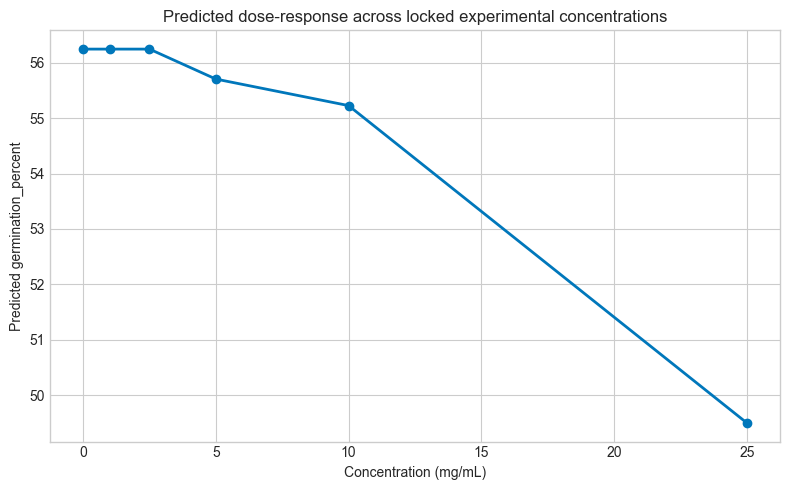

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(trajectory_df["concentration_mg_per_ml"], trajectory_df["predicted"],
        marker="o", color="#0077BB", linewidth=2)
ax.set_xlabel("Concentration (mg/mL)")
ax.set_ylabel(f"Predicted {ENDPOINT_TO_PLOT}")
ax.set_title(f"Predicted dose-response across locked experimental concentrations")
plt.tight_layout()
plt.show()

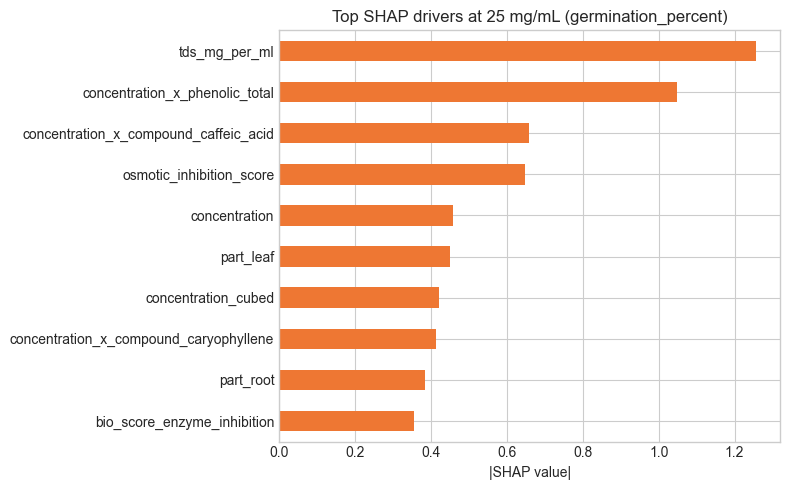

In [14]:
# Which features drive the SHAP prediction at the highest concentration?
high_conc_idx = len(EXP_CONCENTRATIONS) - 1
mean_abs = np.abs(synthetic_shap.values[high_conc_idx])
top_drivers = pd.Series(mean_abs, index=synthetic_rows.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
top_drivers.plot(kind="barh", ax=ax, color="#EE7733")
ax.set_xlabel("|SHAP value|")
ax.set_title(f"Top SHAP drivers at {EXP_CONCENTRATIONS[high_conc_idx]} mg/mL ({ENDPOINT_TO_PLOT})")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Notes for next stage

Things worth flagging before locking predictions:

- Do the top SHAP drivers per endpoint align with known phytochemistry
  (e.g., lantadenes/terpenoids driving inhibition, flavonoids showing
  antioxidant-linked effects)? Flag anything that looks like it's
  picking up a confound (e.g., `osmotic_inhibition_score` dominating
  every endpoint would be a red flag for over-reliance on the osmotic
  proxy rather than genuine phytochemical signal).
- Check whether dependence plots show plausible biological shapes
  (e.g., hormetic low-dose stimulation / high-dose inhibition) rather
  than noisy step functions, which would suggest overfitting.
- Re-run this notebook for each endpoint (`ENDPOINT_TO_PLOT`) before
  finalising the model.

Proceed to `05_final_validation.ipynb` after wet-lab experiments are
complete and Modules 10–11 have run.